# XGBoost

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
import joblib

In [15]:

DECISION_THRESHOLD = 0.5  # raise to favor precision, lower to favor recall on attacks
df = pd.read_csv('Data/struct/features_main_struct.csv', keep_default_na=False)
temporal_df = pd.read_csv('Data/struct/features_test_temporal_struct.csv', keep_default_na=False)
obfuscated_df = pd.read_csv('Data/struct/features_test_obfuscated_struct.csv', keep_default_na=False)
notinject_df = pd.read_csv('Data/struct/features_test_notinject_struct.csv', keep_default_na=False)


In [16]:
print("Split values found in main dataset:", df['split'].unique())
id_cols = ['uid', 'split', 'label', 'source', 'attack_type']
feature_cols = [c for c in df.columns if c not in id_cols]

Split values found in main dataset: <StringArray>
['train', 'val', 'test']
Length: 3, dtype: str


In [17]:
train_df = df[df['split'] == 'train']
val_df = df[df['split'] == 'val']
test_df = df[df['split'] == 'test']
train_uids = set(train_df['uid'])
eval_sets = {
    'val': val_df,
    'test': test_df,
    'temporal': temporal_df,
    'obfuscated': obfuscated_df,
    'notinject': notinject_df,
}
for name, edf in eval_sets.items():
    overlap = train_uids & set(edf['uid'])
    if overlap:
        print(f"WARNING: {len(overlap)} uid(s) shared between train and {name} — check for leakage")

X_train, y_train = train_df[feature_cols], train_df['label']
X_val, y_val = val_df[feature_cols], val_df['label']

In [18]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight (neg/pos): {scale_pos_weight:.3f}")

scale_pos_weight (neg/pos): 1.690


In [19]:
model = xgb.XGBClassifier(
    max_depth=3,
    learning_rate=0.01,
    n_estimators=999,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [20]:
def evaluate(df_test, name, threshold=DECISION_THRESHOLD, plot=True):
    X = df_test[feature_cols]
    y = df_test['label']

    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)

    print(f"\n--- {name} (n={len(y)}, threshold={threshold}) ---")

    if y.nunique() == 1:
        only_class = y.iloc[0]
        if only_class == 0:
            fpr = (preds == 1).mean()
            print(f"All-benign set. False Positive Rate: {fpr:.4f}")
        else:
            fnr = (preds == 0).mean()
            print(f"All-attack set. False Negative Rate: {fnr:.4f}  |  Recall: {1 - fnr:.4f}")
    else:
        print("Accuracy:", accuracy_score(y, preds))
        print(classification_report(y, preds))

    if plot:
        cm = confusion_matrix(y, preds, labels=[0, 1])
        plt.figure()
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Predicted Benign', 'Predicted Attack'],
                    yticklabels=['Actual Benign', 'Actual Attack'])
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.title(f'Confusion Matrix — {name}')
        plt.show()

    return df_test, preds, probs

--- Training Set ---
Accuracy: 0.9242266971143865
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      6052
           1       0.92      0.87      0.90      3582

    accuracy                           0.92      9634
   macro avg       0.92      0.91      0.92      9634
weighted avg       0.92      0.92      0.92      9634


--- Validation (n=1927, threshold=0.5) ---
Accuracy: 0.9122989102231448
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      1210
           1       0.90      0.86      0.88       717

    accuracy                           0.91      1927
   macro avg       0.91      0.90      0.91      1927
weighted avg       0.91      0.91      0.91      1927



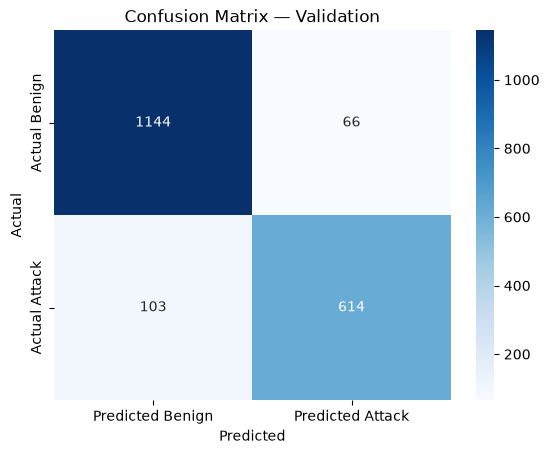


--- Test (main) (n=1928, threshold=0.5) ---
Accuracy: 0.9009336099585062
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      1211
           1       0.90      0.83      0.86       717

    accuracy                           0.90      1928
   macro avg       0.90      0.89      0.89      1928
weighted avg       0.90      0.90      0.90      1928



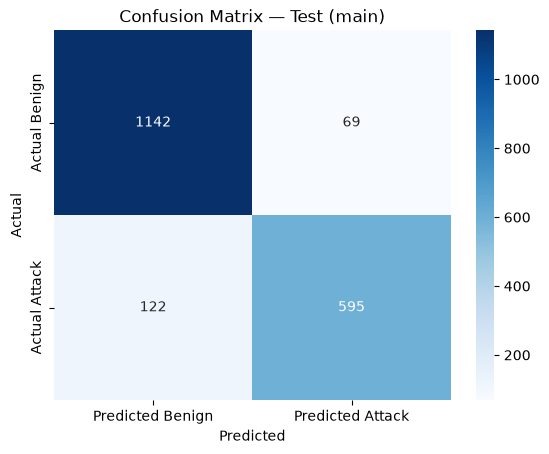

In [21]:
train_preds = model.predict(X_train)
print("--- Training Set ---")
print("Accuracy:", accuracy_score(y_train, train_preds))
print(classification_report(y_train, train_preds))

Val_result = evaluate(val_df, 'Validation')
if not test_df.empty:
    evaluate(test_df, 'Test (main)')


--- Temporal (n=485, threshold=0.5) ---
Accuracy: 0.6474226804123712
              precision    recall  f1-score   support

           0       0.72      0.72      0.72       308
           1       0.52      0.53      0.52       177

    accuracy                           0.65       485
   macro avg       0.62      0.62      0.62       485
weighted avg       0.65      0.65      0.65       485



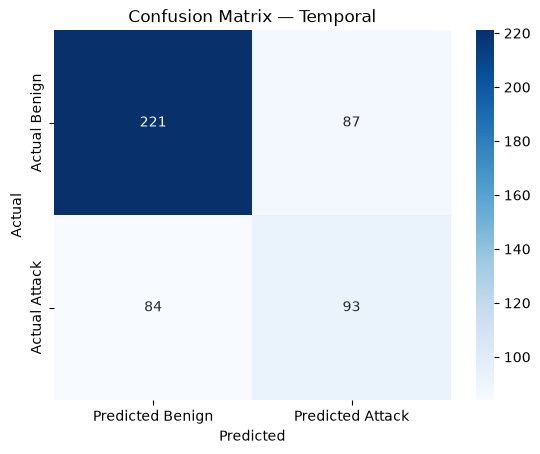


--- Obfuscated (n=1800, threshold=0.5) ---
Accuracy: 0.8472222222222222
              precision    recall  f1-score   support

           0       0.79      0.94      0.86       900
           1       0.93      0.75      0.83       900

    accuracy                           0.85      1800
   macro avg       0.86      0.85      0.85      1800
weighted avg       0.86      0.85      0.85      1800



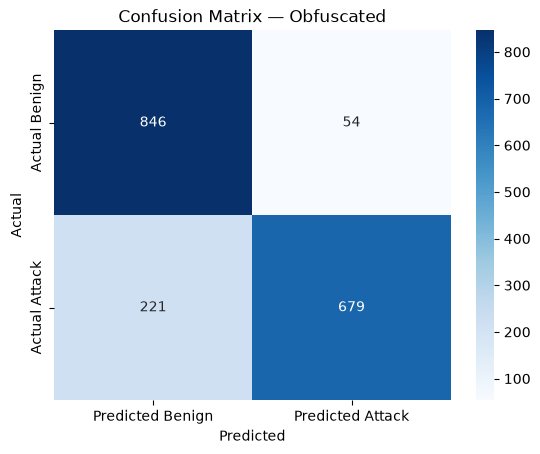


--- Notinject (n=339, threshold=0.5) ---
All-benign set. False Positive Rate: 0.2271


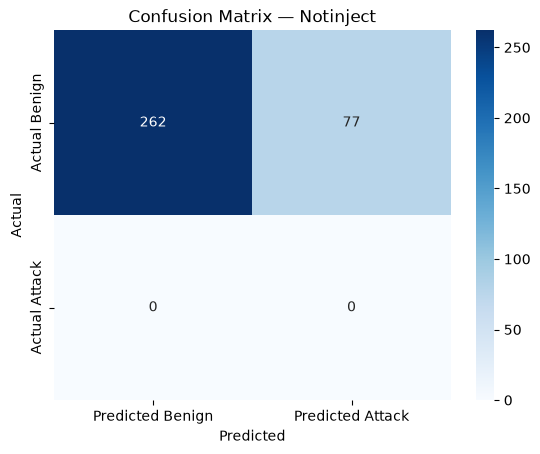


--- Combined targeted stress tests (temporal + obfuscated + notinject) (n=2624, threshold=0.5) ---
Accuracy: 0.8006859756097561
              precision    recall  f1-score   support

           0       0.81      0.86      0.84      1547
           1       0.78      0.72      0.75      1077

    accuracy                           0.80      2624
   macro avg       0.80      0.79      0.79      2624
weighted avg       0.80      0.80      0.80      2624



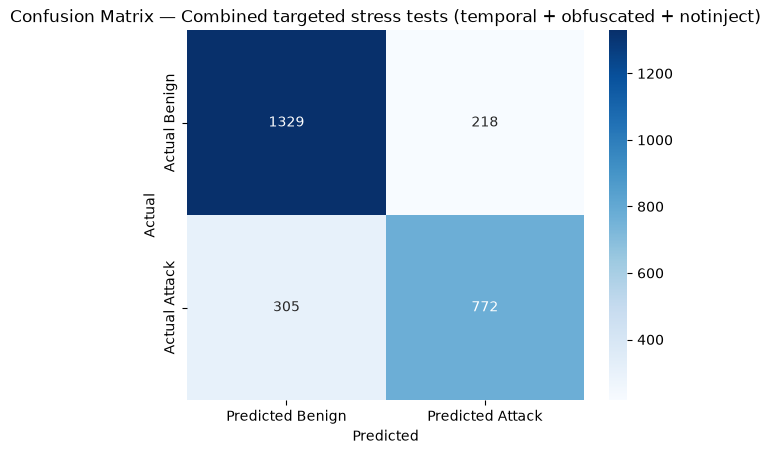

In [22]:
temp_df, temp_preds, temp_probs = evaluate(temporal_df, 'Temporal')
obf_df, obf_preds, obf_probs = evaluate(obfuscated_df, 'Obfuscated')
notinj_df, notinj_preds, notinj_probs = evaluate(notinject_df, 'Notinject')
combined = pd.concat([temporal_df, obfuscated_df, notinject_df])
combined_result = evaluate(combined, 'Combined targeted stress tests (temporal + obfuscated + notinject)')

In [23]:
MODEL_DIR = "models/xgboost"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(model, f"{MODEL_DIR}/xgb_model.joblib")
joblib.dump(feature_cols, f"{MODEL_DIR}/feature_cols.joblib")
joblib.dump({"decision_threshold": DECISION_THRESHOLD}, f"{MODEL_DIR}/config.joblib")

print("saved to", MODEL_DIR)

saved to models/xgboost


In [24]:
print("Imperative ratio — train attacks:", train_df[train_df['label']==1]['imperative_ratio'].mean())
print("Imperative ratio — train benign:", train_df[train_df['label']==0]['imperative_ratio'].mean())
print("Imperative ratio — notinject (all benign):", notinject_df['imperative_ratio'].mean())

Imperative ratio — train attacks: 0.4565091623230215
Imperative ratio — train benign: 0.06829158112404016
Imperative ratio — notinject (all benign): 0.12831858407079647
